In [1]:
import mne
import numpy as np
import matplotlib.pyplot as plt
from mne.preprocessing import ICA

# Load data
data_path = mne.datasets.sample.data_path()
raw_fif_path = data_path / "MEG" / "sample" / "sample_audvis_raw.fif"
raw = mne.io.read_raw_fif(raw_fif_path, preload=True)

# Pick EEG only
raw.pick('eeg')

# Apply bandpass filter
raw.filter(l_freq=0.1, h_freq=40.0)

# Apply ICA to remove eye blinks
ica = ICA(n_components=15, random_state=42)
ica.fit(raw)
ica.exclude = [0]
raw = ica.apply(raw)

print("Data loaded, filtered, and cleaned!")

Opening raw data file /Users/aleksandraszymanska/mne_data/MNE-sample-data/MEG/sample/sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.
Reading 0 ... 166799  =      0.000 ...   277.714 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 19821 samples (33.001 s)

Fitting ICA to data using 59 channels (please be patient, this may

Effective window size : 3.410 (s)
Plotting power spectral density (dB=True).


/Users/aleksandraszymanska/Desktop/eeg-pipeline/venv/lib/python3.12/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


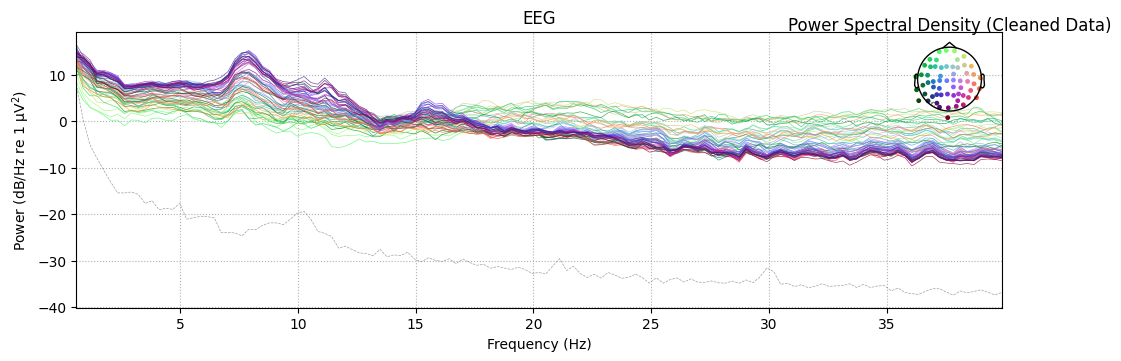

In [2]:
# Compute PSD using Welch's method
fig = raw.compute_psd(fmin=0.5, fmax=40).plot()
plt.title("Power Spectral Density (Cleaned Data)")
plt.show()

Effective window size : 3.410 (s)


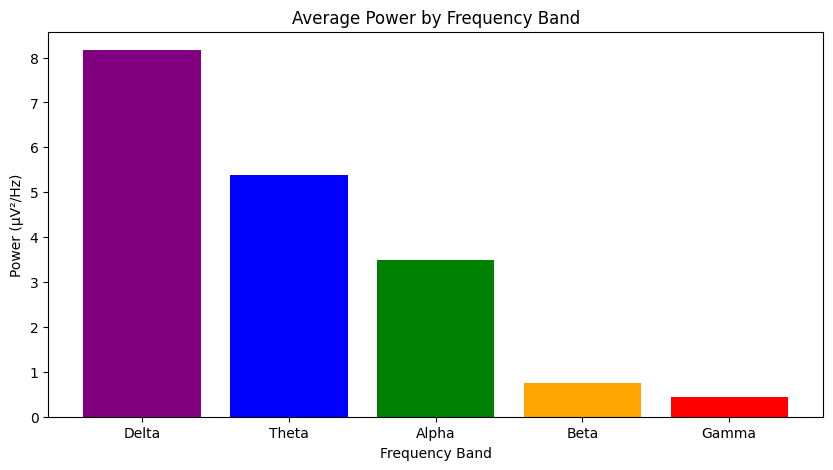

Delta: 8.17 µV²/Hz
Theta: 5.39 µV²/Hz
Alpha: 3.49 µV²/Hz
Beta: 0.76 µV²/Hz
Gamma: 0.45 µV²/Hz


In [3]:
# Define frequency bands
bands = {
    'Delta': (0.5, 4),
    'Theta': (4, 8),
    'Alpha': (8, 12),
    'Beta': (13, 30),
    'Gamma': (30, 40)
}

# Compute PSD
spectrum = raw.compute_psd(fmin=0.5, fmax=40)
psds, freqs = spectrum.get_data(return_freqs=True)

# Calculate mean power in each band
band_power = {}
for band_name, (fmin, fmax) in bands.items():
    # Find frequencies in this band
    idx = (freqs >= fmin) & (freqs <= fmax)
    # Mean power across frequencies and channels
    band_power[band_name] = psds[:, idx].mean() * 1e12  # Convert to pT²/Hz
    
# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(band_power.keys(), band_power.values(), color=['purple', 'blue', 'green', 'orange', 'red'])
ax.set_ylabel('Power (µV²/Hz)')
ax.set_xlabel('Frequency Band')
ax.set_title('Average Power by Frequency Band')
plt.show()

# Print values
for band, power in band_power.items():
    print(f"{band}: {power:.2f} µV²/Hz")

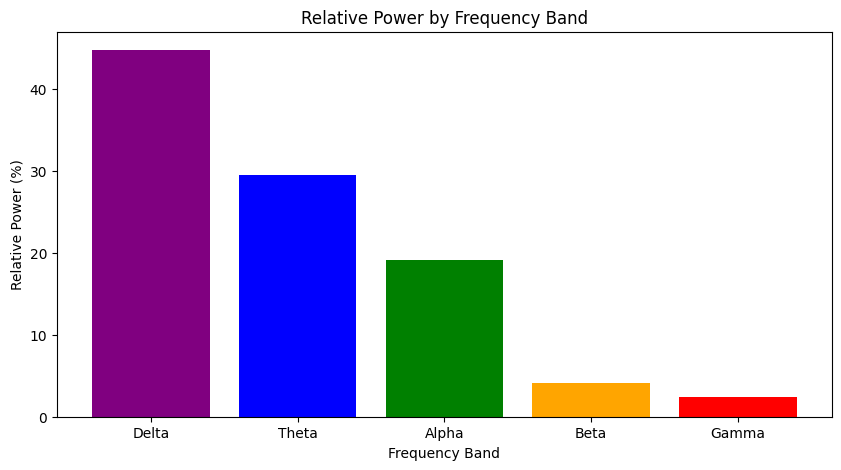

Delta: 44.7%
Theta: 29.5%
Alpha: 19.1%
Beta: 4.1%
Gamma: 2.4%


In [4]:
# Calculate relative (percentage) power
total_power = sum(band_power.values())
relative_power = {band: (power/total_power)*100 for band, power in band_power.items()}

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(relative_power.keys(), relative_power.values(), color=['purple', 'blue', 'green', 'orange', 'red'])
ax.set_ylabel('Relative Power (%)')
ax.set_xlabel('Frequency Band')
ax.set_title('Relative Power by Frequency Band')
plt.show()

# Print values
for band, power in relative_power.items():
    print(f"{band}: {power:.1f}%")

Effective window size : 3.410 (s)


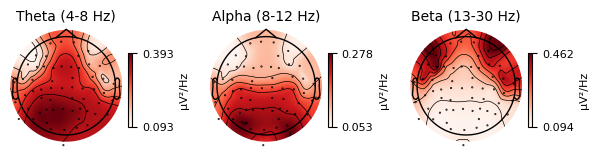

In [8]:
# Compute PSD once
spectrum = raw.compute_psd(fmin=1, fmax=40)

# Define bands for topomap
bands = {'Theta (4-8 Hz)': (4, 8), 'Alpha (8-12 Hz)': (8, 12), 'Beta (13-30 Hz)': (13, 30)}

# Plot topographic maps
spectrum.plot_topomap(bands=bands, normalize=True)
plt.show()